# Disk Modeling Basics

## Introduction

This notebook provides an introduction to the **disk modeling workflow** in `grater-jax`.  
It shows how the framework builds scattered-light disk images from modular components that represent different physical and instrumental effects.

The model is structured into the following pieces:

- **Dust Distribution** – specifies the 3D density of dust grains (e.g., radial power-law slopes, eccentricity, vertical scale height).  
- **Scattering Phase Function (SPF)** – controls how starlight is scattered by dust as a function of angle (Henyey–Greenstein, double HG, or spline-based models).  
- **Point Spread Function (PSF)** – applies instrument response by convolving the model image with a chosen PSF kernel (Gaussian, empirical, etc.).  

The notebook demonstrates how to configure these components, run them through the `objective_model` pipeline, and generate synthetic disk images that can be compared directly with observations.


### Setup

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.15"

from grater_jax.disk_model.objective_functions import objective_model, objective_fit, log_likelihood, Parameter_Index
from grater_jax.disk_model.SLD_utils import DoubleHenyeyGreenstein_SPF, InterpolatedUnivariateSpline_SPF, EMP_PSF, DustEllipticalDistribution2PowerLaws, Winnie_PSF
from grater_jax.disk_model.SLD_ojax import ScatteredLightDisk
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
from astropy.io import fits

jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_debug_nans", True) <-- can use this to trace issues at the cost of runtime

2025-12-23 23:35:45.563677: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


## Generating Disk Models with Simple PSFs

### Empirical PSF Image

In [2]:
# Generates a simple psf function image
scale_factor = 1
image = fits.open("tutorial_images/GPI_Hband_PSF.fits")[0].data[0,:,:]
scaled_image = (image[::scale_factor, ::scale_factor])[1::, 1::]
cropped_image = image[70:211, 70:211]
def safe_float32_conversion(value):
    try:
        return np.float32(value)
    except (ValueError, TypeError):
        print("This value is unjaxable: " + str(value))
emp_psf_image = np.nan_to_num(cropped_image)
emp_psf_image = np.vectorize(safe_float32_conversion)(emp_psf_image)

### Simple Disk Model

In [3]:
EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
spf_params = DoubleHenyeyGreenstein_SPF.params
psf_params = EMP_PSF.params

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
disk_params['sma'] = 40
disk_params['inclination'] = 60
disk_params['position_angle'] = 30

# Initializing the misc parameter dictionary
misc_params = Parameter_Index.misc_params

# Setting flux_scaling to custom value
misc_params['flux_scaling'] = 1e4

simple_disk_img = objective_model(disk_params, spf_params, psf_params, misc_params,
                        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, DoubleHenyeyGreenstein_SPF, EMP_PSF)

#### Disk Model Image

Text(0.5, 1.0, 'Simple Scattered Light Disk Model')

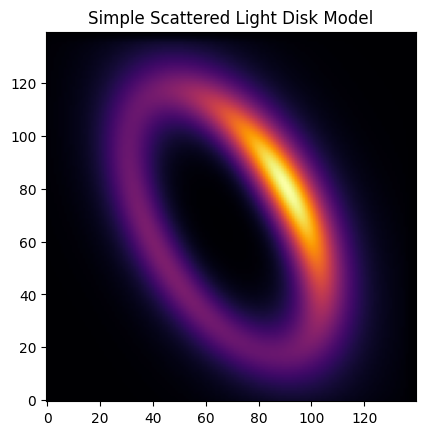

In [4]:
plt.imshow(simple_disk_img, origin='lower', cmap='inferno')
plt.title('Simple Scattered Light Disk Model')

#### Runtime Analysis

In [5]:
%timeit objective_model(disk_params, spf_params, psf_params, Parameter_Index.misc_params, ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, DoubleHenyeyGreenstein_SPF, EMP_PSF)

2.17 ms ± 1.63 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Forward Modeling

#### Generating a Target Disk

Text(0.5, 1.0, 'Target Disk')

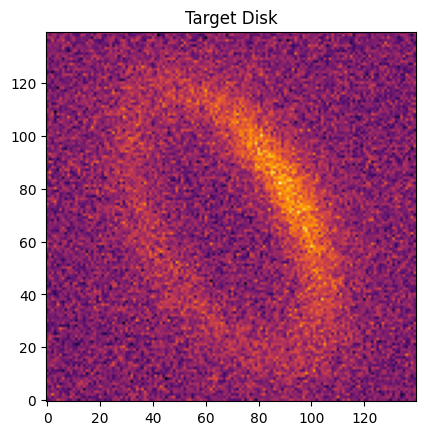

In [6]:
noise_level = 1
noise = np.random.normal(0, noise_level, simple_disk_img.shape)
target_image = simple_disk_img + noise
err_map = jnp.ones(simple_disk_img.shape)*noise_level
plt.imshow(target_image, origin='lower', cmap='inferno')
plt.title('Target Disk')

### Getting the Log-Likelihood

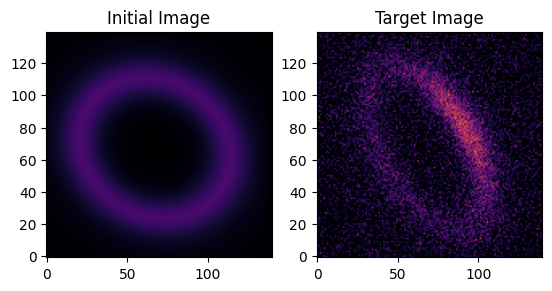

Log-Likelihood: -0.8488484518528874


In [7]:
EMP_PSF.img = emp_psf_image

# Using parameters dictionaries from SLD_utils
start_spf_params = InterpolatedUnivariateSpline_SPF.params
start_psf_params = EMP_PSF.params

# Initializing spline spf parameters
start_spf_params['num_knots'] = 5
start_spf_params['knot_values'] = jnp.ones(5)*0.1
start_spf_params['backscatt_bound'] = -0.9
start_spf_params['frontscatt_bound'] = 0.9

# Initializing the disk parameter dictionary (all the possible parameters that can be configured)
start_disk_params = Parameter_Index.disk_params

# Setting certain parameters to custom values
start_disk_params['sma'] = 35
start_disk_params['inclination'] = 30
start_disk_params['position_angle'] = 60

misc_params = Parameter_Index.misc_params
misc_params['flux_scaling'] = 1e4

start_image = objective_model(start_disk_params, start_spf_params, start_psf_params, Parameter_Index.misc_params,
                        ScatteredLightDisk, DustEllipticalDistribution2PowerLaws, InterpolatedUnivariateSpline_SPF, EMP_PSF)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(start_image, origin='lower', cmap='inferno', vmin=0, vmax=10)
axes[0].set_title('Initial Image')
axes[1].imshow(target_image, origin='lower', cmap='inferno', vmin=0, vmax=10)
axes[1].set_title('Target Image')
plt.show()

print(f'Log-Likelihood: {log_likelihood(start_image, target_image, err_map)}')

### Disk Fitting using Scipy Optimize Minimize

In [8]:
from scipy.optimize import minimize

# Specifying parameters to be fit
fit_keys = ['sma', 'inclination', 'position_angle', 'knot_values']

# Creating objective function
llp = lambda x: -objective_fit([x[0], x[1], x[2], x[3:]], fit_keys, start_disk_params, start_spf_params, start_psf_params,
                               Parameter_Index.misc_params, ScatteredLightDisk, DustEllipticalDistribution2PowerLaws,
                               InterpolatedUnivariateSpline_SPF, EMP_PSF, target_image, err_map)

# Initial Parameters (need to be in array form)
init_x = jnp.concatenate([jnp.array([start_disk_params['sma'], start_disk_params['inclination'], start_disk_params['position_angle']]), start_spf_params['knot_values']])

soln = minimize(llp, init_x, method='Nelder-Mead', options={'disp': True, 'maxiter': 500})


print(soln)

       message: Maximum number of iterations has been exceeded.
       success: False
        status: 2
           fun: 0.5097832662963018
             x: [ 4.074e+01  6.071e+01  2.941e+01  2.602e-01  7.789e-02
                  6.008e-02  5.488e-02  8.125e-02]
           nit: 500
          nfev: 716
 final_simplex: (array([[ 4.074e+01,  6.071e+01, ...,  5.488e-02,
                         8.125e-02],
                       [ 4.080e+01,  6.076e+01, ...,  5.530e-02,
                         8.087e-02],
                       ...,
                       [ 4.074e+01,  6.074e+01, ...,  5.685e-02,
                         7.957e-02],
                       [ 4.082e+01,  6.078e+01, ...,  5.561e-02,
                         8.158e-02]], shape=(9, 8)), array([ 5.098e-01,  5.099e-01,  5.099e-01,  5.099e-01,
                        5.099e-01,  5.099e-01,  5.099e-01,  5.100e-01,
                        5.100e-01]))


/tmp/ipykernel_1242695/1663551463.py:14: RuntimeWarning: Maximum number of iterations has been exceeded.
  soln = minimize(llp, init_x, method='Nelder-Mead', options={'disp': True, 'maxiter': 500})


#### Numeric Results

In [9]:
print(f"Disk Fit Log Likelihood: {-soln.fun}")

Disk Fit Log Likelihood: -0.5097832662963018


#### Visual Results

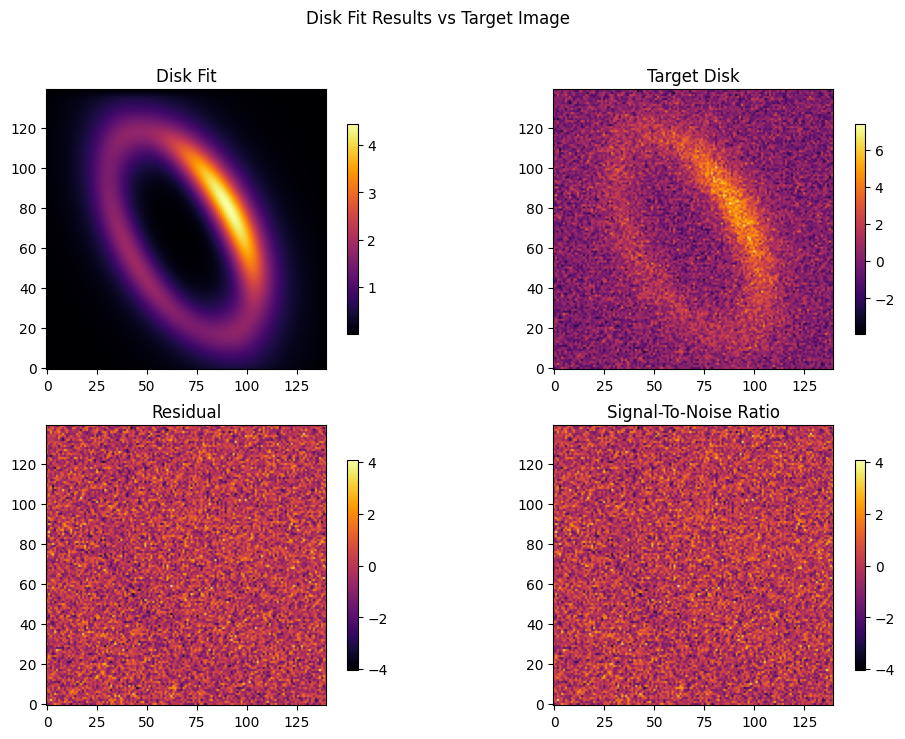

In [10]:
new_disk_params = disk_params.copy()
new_spf_params = start_spf_params.copy()
new_disk_params['sma'] = soln.x[0]
new_disk_params['inclination'] = soln.x[1]
new_disk_params['position_angle'] = soln.x[2]
new_spf_params['knot_values'] = soln.x[3:]

fitted_image = objective_model(new_disk_params, new_spf_params, psf_params, Parameter_Index.misc_params, ScatteredLightDisk, DustEllipticalDistribution2PowerLaws,
                                InterpolatedUnivariateSpline_SPF, EMP_PSF)

fig, axes = plt.subplots(2, 2, figsize=(12,8))

fitted_pic = axes[0][0].imshow(fitted_image, origin='lower', cmap='inferno')
axes[0][0].set_title('Disk Fit')
plt.colorbar(fitted_pic, ax=axes[0][0], shrink=0.75)

target_pic = axes[0][1].imshow(target_image, origin='lower', cmap='inferno')
axes[0][1].set_title('Target Disk')
plt.colorbar(target_pic, ax=axes[0][1], shrink=0.75)

residual_pic = axes[1][0].imshow(target_image-fitted_image, origin='lower', cmap='inferno')
axes[1][0].set_title('Residual')
plt.colorbar(residual_pic, ax=axes[1][0], shrink=0.75)

residual_pic = axes[1][1].imshow(np.where(err_map == 0, 0., (target_image-fitted_image)/err_map), origin='lower', cmap='inferno')
axes[1][1].set_title('Signal-To-Noise Ratio')
plt.colorbar(residual_pic, ax=axes[1][1], shrink=0.75)

fig.suptitle("Disk Fit Results vs Target Image")
plt.show()

#### Spline Fit Results

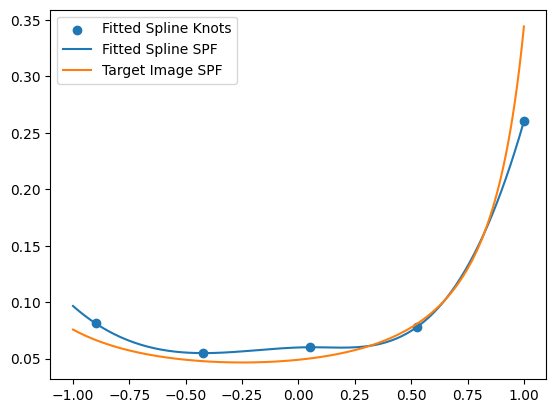

In [11]:
x_vals = jnp.linspace(-1, 1, 200)
knot_locs = InterpolatedUnivariateSpline_SPF.get_knots(new_spf_params)
plt.scatter(knot_locs, InterpolatedUnivariateSpline_SPF.pack_pars(new_spf_params['knot_values'],
                    knots=knot_locs)(knot_locs))
plt.plot(x_vals, InterpolatedUnivariateSpline_SPF.pack_pars(new_spf_params['knot_values'],
                    knots=knot_locs)(x_vals))
plt.plot(x_vals, DoubleHenyeyGreenstein_SPF.compute_phase_function_from_cosphi(DoubleHenyeyGreenstein_SPF.pack_pars(spf_params), x_vals))

plt.legend(['Fitted Spline Knots', 'Fitted Spline SPF', 'Target Image SPF'])

## Takeaways

As you can see, the objective functions provide a useful utility for fitting disks with great accuracy. However, for more complicated models, the process for fitting a disk with just the objective function is very cumbersome and not as precise. If you want a simpler way to work with more complex disks, leverage autodifferentiation, and run comprehensive sampling algorithms, refer to the Advanced Disk Modeling tutorial where we demonstrate the Optimizer class.